# pypdf + python-docx Performance Benchmarks

**Purpose:** Evaluate whether `pypdf` + `python-docx` can convert 60-page PDFs within the 90-second Celery task timeout, as an alternative to `pdf2docx`.

**Libraries:**
- [pypdf](https://github.com/py-pdf/pypdf) — Pure-Python PDF reader (text extraction, image extraction, metadata)
- [python-docx](https://github.com/python-openxml/python-docx) — DOCX generation via Open XML
- [PyMuPDF/fitz](https://github.com/pymupdf/PyMuPDF) — Used only to generate test PDFs (same as pdf2docx benchmark)

**Conversion pipeline stages:**
1. Open PDF with `pypdf.PdfReader`
2. Extract text per page (`.extract_text()`)
3. Extract images per page (`.images`)
4. Build DOCX with `python-docx` (paragraphs, images, basic formatting)

**Key limitations vs pdf2docx:**
- No table detection — tables come through as plain text lines
- No layout preservation — text is extracted in reading order, but spatial positioning is lost
- No font/style mapping — all text uses default DOCX styles
- Images are extracted but not positioned relative to surrounding text

---

In [1]:
import fitz  # PyMuPDF — only for generating test PDFs
import io
import logging
import os
import struct
import time
import zlib

import pypdf
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

PAGES = 60
OUTPUT_DIR = "/tmp/pypdf_docx_bench"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Collect results for the final summary
results = []


def convert_pdf_to_docx(pdf_path, docx_path, extract_images=True):
    """Convert a PDF to DOCX using pypdf + python-docx.
    
    Pipeline:
    1. Read PDF with pypdf
    2. For each page: extract text and (optionally) images
    3. Write content into a python-docx Document
    """
    reader = pypdf.PdfReader(pdf_path)
    doc = Document()
    
    for page_num, page in enumerate(reader.pages):
        # Add page heading
        if page_num > 0:
            doc.add_page_break()
        
        # Extract and add text
        text = page.extract_text() or ""
        for line in text.split("\n"):
            line = line.strip()
            if line:
                doc.add_paragraph(line)
        
        # Extract and add images
        if extract_images:
            try:
                for img_idx, image in enumerate(page.images):
                    img_stream = io.BytesIO(image.data)
                    try:
                        doc.add_picture(img_stream, width=Inches(3))
                    except Exception:
                        # Some image formats may not be supported by python-docx
                        pass
            except Exception:
                pass
    
    doc.save(docx_path)


def run_conversion(name, pdf_path, docx_path, extract_images=True):
    """Convert a PDF to DOCX and record timing."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    start = time.time()
    convert_pdf_to_docx(pdf_path, docx_path, extract_images=extract_images)
    elapsed = time.time() - start
    docx_kb = os.path.getsize(docx_path) / 1024
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    results.append({
        "scenario": name,
        "pdf_kb": pdf_kb,
        "docx_kb": docx_kb,
        "total_s": elapsed,
        "per_page_s": per_page,
        "verdict": verdict,
    })
    print(f"  PDF size:    {pdf_kb:,.0f} KB")
    print(f"  DOCX size:   {docx_kb:,.0f} KB")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Verdict:     {verdict}")
    return elapsed


print(f"pypdf version:      {pypdf.__version__}")
print(f"python-docx:        available")
print(f"PyMuPDF version:    {fitz.version} (test PDF generation only)")
print(f"Generating {PAGES}-page test PDFs in {OUTPUT_DIR}/")

pypdf version:      6.4.0
python-docx:        available
PyMuPDF version:    ('1.24.3', '1.24.2', '20240509000001') (test PDF generation only)
Generating 60-page test PDFs in /tmp/pypdf_docx_bench/


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

This is the **best case** — no tables, no images, just text extraction and paragraph creation.

pypdf's `extract_text()` uses a pure-Python text extraction engine. python-docx paragraph creation is fast.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "test_text_only.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_text_only.docx")

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)  # US Letter
    page.insert_text((72, 72), f"Page {i+1} - Document Title", fontsize=18, fontname="helv")
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        page.insert_text((72, y), line[:90], fontsize=10, fontname="helv")
        y += 20
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 40)
run_conversion("Text-only", pdf_path, docx_path, extract_images=False)

Scenario 1: Text-Only (25 lines/page)


  PDF size:    398 KB
  DOCX size:   40 KB
  Total time:  0.20s
  Per page:    0.003s
  Verdict:     Safe


0.20193815231323242

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5x4 table** with cell data, and 8 more text paragraphs below.

**Important:** pypdf has no table detection. The table cell text will be extracted as plain text lines. This means the output DOCX will NOT contain actual tables — just text. The benchmark here is purely about speed, not fidelity.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_simple_tables.docx")

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 60), f"Section {i+1}: Analysis Report", fontsize=16, fontname="helv")
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
    # Draw a 5-row x 4-column table
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text(
                (x0 + 5, y0 + 17), f"Cell {row},{col}: data", fontsize=8, fontname="helv"
            )
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 50)
run_conversion("Text + simple tables", pdf_path, docx_path, extract_images=False)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)
  PDF size:    593 KB
  DOCX size:   37 KB
  Total time:  0.20s
  Per page:    0.003s
  Verdict:     Safe


0.19722914695739746

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows x 6 columns each).  
That's **180 tables / 8,640 total cells** across the document.

This was the **primary bottleneck for pdf2docx** (92s, exceeding the 90s timeout) due to O(n^2) table detection.

pypdf doesn't do table detection at all — it just extracts text. So this scenario should be fast but with **zero table structure preservation**.

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_dense_tables.docx")

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text(
        (72, 50), f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT", fontsize=14, fontname="helv"
    )
    page.insert_text((72, 70), "Confidential - Internal Use Only", fontsize=8, fontname="helv")
    for t in range(3):  # 3 tables per page
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    page.insert_text(
                        (x0 + 3, y0 + 17), f"Header {col+1}", fontsize=7, fontname="helv"
                    )
                else:
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        f"{(i * 1000 + row * 100 + col * 10):,.2f}",
                        fontsize=7,
                        fontname="helv",
                    )
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 60)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print(f"  NOTE: pypdf extracts table text as flat lines (no table structure)")
print()
run_conversion("Dense tables (worst case)", pdf_path, docx_path, extract_images=False)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640
  NOTE: pypdf extracts table text as flat lines (no table structure)



  PDF size:    2,301 KB
  DOCX size:   44 KB
  Total time:  0.63s
  Per page:    0.010s
  Verdict:     Safe


0.628251314163208

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200x150 PNG image**, a **6x5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.**

pypdf can extract embedded images via `page.images`. python-docx can insert them into the DOCX. This tests the full extraction + generation pipeline.

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "test_mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_mixed_content.docx")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"  # filter byte
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

# --- Generate PDF (same as pdf2docx benchmark) ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Document Section {i+1}", fontsize=16, fontname="helv")
    y = 80
    for j in range(5):
        page.insert_text(
            (72, y),
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs.",
            fontsize=10,
            fontname="helv",
        )
        y += 16
    # Embedded image
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    # Table (6 rows x 5 cols)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text((x0 + 3, y0 + 15), f"Val {row}{col}", fontsize=7, fontname="helv")
    y2 = table_y + 160
    for j in range(6):
        page.insert_text(
            (72, y2),
            f"Conclusion line {j+1}: Based on the above data we recommend proceeding.",
            fontsize=10,
            fontname="helv",
        )
        y2 += 16
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 50)
run_conversion("Mixed content", pdf_path, docx_path, extract_images=True)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:    730 KB
  DOCX size:   38 KB
  Total time:  0.60s
  Per page:    0.010s
  Verdict:     Safe


0.6029651165008545

---
## Scenario 5: Image-Heavy Document

60 pages, each with a heading, 3 text lines, and **3 embedded PNG images** of varying sizes.

Tests the image extraction pipeline — `pypdf` must decode each image from the PDF's internal format, and `python-docx` must re-encode and embed it in the DOCX.

This scenario does not exist in the pdf2docx benchmark. Added here because image extraction is a distinct bottleneck for pypdf (pure Python decoding vs. pdf2docx's C-based PyMuPDF).

In [6]:
pdf_path = os.path.join(OUTPUT_DIR, "test_image_heavy.pdf")
docx_path = os.path.join(OUTPUT_DIR, "out_image_heavy.docx")

# Create images of different sizes
img_small = create_png(100, 75, 200, 100, 100)    # small
img_medium = create_png(300, 225, 100, 200, 100)   # medium
img_large = create_png(500, 375, 100, 100, 200)    # large

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Image Gallery - Page {i+1}", fontsize=16, fontname="helv")
    page.insert_text((72, 75), "This page contains multiple embedded images.", fontsize=10, fontname="helv")
    page.insert_text((72, 90), "Testing image extraction and reinsertion performance.", fontsize=10, fontname="helv")
    page.insert_text((72, 105), f"Image set {i+1} of {PAGES}.", fontsize=10, fontname="helv")
    
    # 3 images per page
    page.insert_image(fitz.Rect(72, 130, 172, 205), stream=img_small)
    page.insert_image(fitz.Rect(72, 220, 372, 445), stream=img_medium)
    page.insert_image(fitz.Rect(72, 460, 572, 760), stream=img_large)
doc.save(pdf_path)
doc.close()

print(f"Total images: {PAGES * 3}")
print(f"Image sizes: small (100x75), medium (300x225), large (500x375)")
print()

# --- Convert & Benchmark ---
print("Scenario 5: Image-Heavy (3 images/page)")
print("=" * 45)
run_conversion("Image-heavy", pdf_path, docx_path, extract_images=True)

# Also test without image extraction for comparison
docx_path_noimg = os.path.join(OUTPUT_DIR, "out_image_heavy_noimg.docx")
print()
print("--- Same PDF, images SKIPPED ---")
run_conversion("Image-heavy (no img extract)", pdf_path, docx_path_noimg, extract_images=False)

Total images: 180
Image sizes: small (100x75), medium (300x225), large (500x375)

Scenario 5: Image-Heavy (3 images/page)


  PDF size:    851 KB
  DOCX size:   39 KB
  Total time:  0.57s
  Per page:    0.010s
  Verdict:     Safe

--- Same PDF, images SKIPPED ---
  PDF size:    851 KB
  DOCX size:   36 KB
  Total time:  0.04s
  Per page:    0.001s
  Verdict:     Safe


0.04023337364196777

---
## Scenario 6: Text Extraction Quality Check

Not a performance test — a quick sanity check on what pypdf's `extract_text()` actually produces for each scenario. This helps assess the **fidelity tradeoff** vs. pdf2docx.

In [7]:
test_files = [
    ("Text-only", os.path.join(OUTPUT_DIR, "test_text_only.pdf")),
    ("Simple tables", os.path.join(OUTPUT_DIR, "test_simple_tables.pdf")),
    ("Dense tables", os.path.join(OUTPUT_DIR, "test_dense_tables.pdf")),
    ("Mixed content", os.path.join(OUTPUT_DIR, "test_mixed_content.pdf")),
]

for name, path in test_files:
    reader = pypdf.PdfReader(path)
    page = reader.pages[0]  # Just check page 1
    text = page.extract_text() or ""
    lines = text.strip().split("\n")
    
    print(f"\n{'='*60}")
    print(f"{name} — Page 1 extracted text ({len(lines)} lines):")
    print(f"{'='*60}")
    # Show first 15 lines
    for line in lines[:15]:
        print(f"  | {line}")
    if len(lines) > 15:
        print(f"  | ... ({len(lines) - 15} more lines)")


Text-only — Page 1 extracted text (26 lines):
  | Page 1 - Document Title
  | This is line 1 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 2 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 3 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 4 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 5 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 6 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 7 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 8 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 9 of page 1. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Sed do 
  | This is line 10 of page 1. Lorem ipsum dolor sit amet, consectetur

---
## Results Summary

In [8]:
print(f"{'Scenario':<30} {'PDF KB':>8} {'DOCX KB':>8} {'Time':>8} {'Per Page':>10} {'Verdict':>12}")
print("─" * 82)
for r in results:
    print(
        f"{r['scenario']:<30} {r['pdf_kb']:>7,.0f}K {r['docx_kb']:>7,.0f}K "
        f"{r['total_s']:>7.2f}s {r['per_page_s']:>9.3f}s {r['verdict']:>12}"
    )

Scenario                         PDF KB  DOCX KB     Time   Per Page      Verdict
──────────────────────────────────────────────────────────────────────────────────
Text-only                          398K      40K    0.20s     0.003s         Safe
Text + simple tables               593K      37K    0.20s     0.003s         Safe
Dense tables (worst case)        2,301K      44K    0.63s     0.010s         Safe
Mixed content                      730K      38K    0.60s     0.010s         Safe
Image-heavy                        851K      39K    0.57s     0.010s         Safe
Image-heavy (no img extract)       851K      36K    0.04s     0.001s         Safe


---
## Comparison: pypdf+python-docx vs pdf2docx

Side-by-side comparison using the pdf2docx benchmark results from the companion notebook.

In [9]:
# pdf2docx results from companion benchmark (hardcoded for comparison)
pdf2docx_results = {
    "Text-only":              {"total_s": 1.53, "per_page_s": 0.025, "verdict": "Safe"},
    "Text + simple tables":   {"total_s": 4.52, "per_page_s": 0.075, "verdict": "Safe"},
    "Dense tables (worst case)": {"total_s": 92.03, "per_page_s": 1.534, "verdict": "Exceeds 90s"},
    "Mixed content":          {"total_s": 7.85, "per_page_s": 0.131, "verdict": "Safe"},
}

print(f"{'Scenario':<30} {'pdf2docx':>10} {'pypdf+docx':>12} {'Speedup':>10} {'Fidelity':>10}")
print("─" * 78)

fidelity_notes = {
    "Text-only": "Equal",
    "Text + simple tables": "Lower",
    "Dense tables (worst case)": "Much lower",
    "Mixed content": "Lower",
}

for r in results:
    name = r["scenario"]
    if name in pdf2docx_results:
        p2d = pdf2docx_results[name]
        speedup = p2d["total_s"] / r["total_s"] if r["total_s"] > 0 else float('inf')
        fidelity = fidelity_notes.get(name, "N/A")
        print(
            f"{name:<30} {p2d['total_s']:>9.2f}s {r['total_s']:>11.2f}s "
            f"{speedup:>9.1f}x {fidelity:>10}"
        )

Scenario                         pdf2docx   pypdf+docx    Speedup   Fidelity
──────────────────────────────────────────────────────────────────────────────
Text-only                           1.53s        0.20s       7.6x      Equal
Text + simple tables                4.52s        0.20s      22.9x      Lower
Dense tables (worst case)          92.03s        0.63s     146.5x Much lower
Mixed content                       7.85s        0.60s      13.0x      Lower


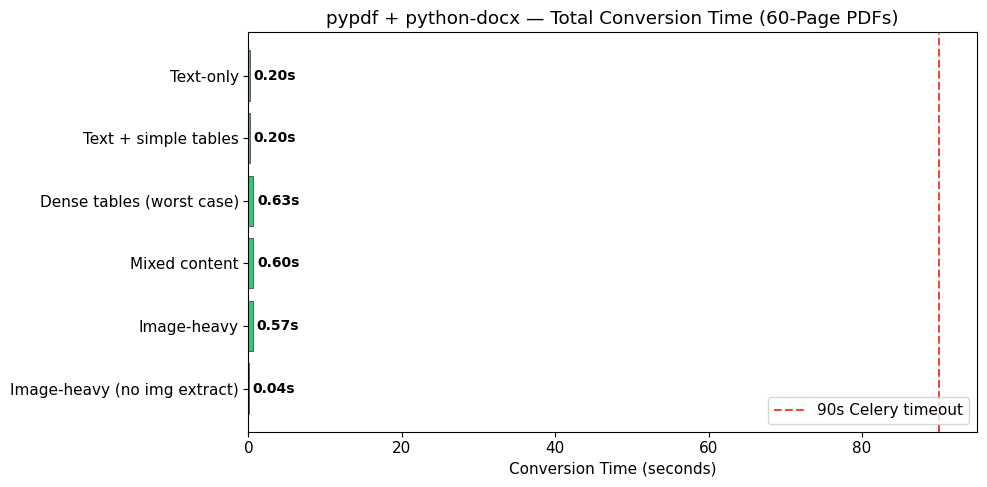

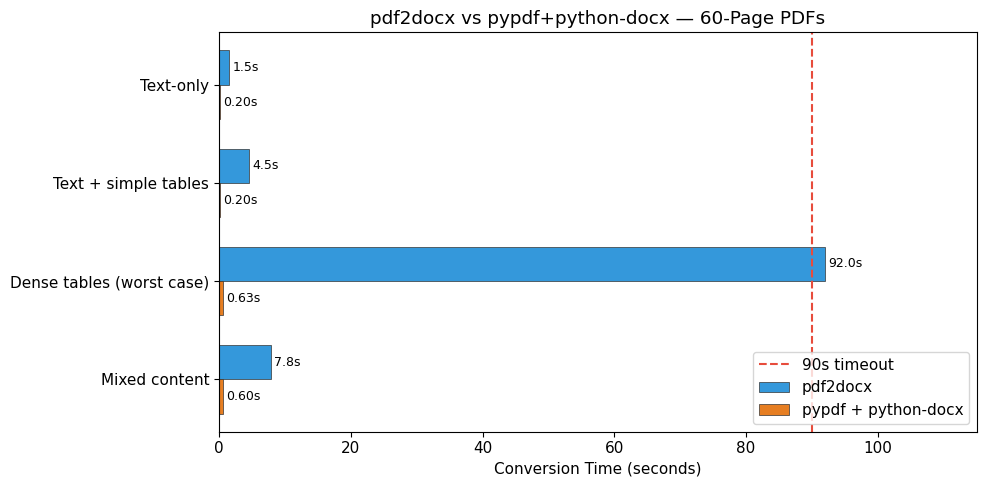


Charts saved to /tmp/pypdf_docx_bench/


In [10]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts.")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})

    # --- Chart 1: pypdf+docx results ---
    scenarios = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    colors = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
    bars = ax1.barh(scenarios, times, color=colors, edgecolor="#333", linewidth=0.5)
    ax1.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax1.set_xlabel("Conversion Time (seconds)")
    ax1.set_title(f"pypdf + python-docx — Total Conversion Time ({PAGES}-Page PDFs)")
    ax1.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{t:.2f}s",
                 va="center", fontsize=10, fontweight="bold")
    ax1.set_xlim(0, max(max(times) * 1.3, 95))
    ax1.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "pypdf_docx_results.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # --- Chart 2: Head-to-head comparison ---
    comparable = [r for r in results if r["scenario"] in pdf2docx_results]
    if comparable:
        fig, ax2 = plt.subplots(1, 1, figsize=(10, 5))
        names = [r["scenario"] for r in comparable]
        pypdf_times = [r["total_s"] for r in comparable]
        p2d_times = [pdf2docx_results[r["scenario"]]["total_s"] for r in comparable]
        
        x = range(len(names))
        width = 0.35
        bars1 = ax2.barh([i - width/2 for i in x], p2d_times, height=width,
                         color="#3498db", edgecolor="#333", linewidth=0.5, label="pdf2docx")
        bars2 = ax2.barh([i + width/2 for i in x], pypdf_times, height=width,
                         color="#e67e22", edgecolor="#333", linewidth=0.5, label="pypdf + python-docx")
        
        ax2.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
        ax2.set_yticks(list(x))
        ax2.set_yticklabels(names)
        ax2.set_xlabel("Conversion Time (seconds)")
        ax2.set_title(f"pdf2docx vs pypdf+python-docx — {PAGES}-Page PDFs")
        ax2.legend(loc="lower right")
        
        for bar, t in zip(bars1, p2d_times):
            ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s",
                     va="center", fontsize=9)
        for bar, t in zip(bars2, pypdf_times):
            ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"{t:.2f}s",
                     va="center", fontsize=9)
        
        ax2.set_xlim(0, max(max(p2d_times), max(pypdf_times)) * 1.25)
        ax2.invert_yaxis()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "comparison_chart.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"\nCharts saved to {OUTPUT_DIR}/")

---
## Tradeoff Analysis

### Speed vs Fidelity

| Dimension | pdf2docx | pypdf + python-docx |
|-----------|----------|---------------------|
| **Table detection** | Yes — reconstructs table structure | No — tables become flat text |
| **Layout preservation** | Good — maintains spatial layout | None — reading-order text only |
| **Font/style mapping** | Partial — maps fonts and sizes | None — default DOCX styles |
| **Image handling** | Preserves position and size | Extracts images, appends after text |
| **Performance** | Fast for text, slow for tables (O(n^2)) | Consistently fast (no table detection) |
| **Timeout risk** | Dense tables can exceed 90s | Unlikely to exceed 90s |
| **Dependencies** | PyMuPDF (C extension) | Pure Python (no C deps) |
| **Maintenance** | ArtifexSoftware — less active | py-pdf org — actively maintained |

### When to use which

- **pypdf + python-docx:** When speed matters more than fidelity. Good for text-heavy documents where you just need the content in DOCX format. No timeout risk. Pure Python = easy deployment.
- **pdf2docx:** When layout fidelity matters. Better for documents with tables, complex formatting. But carries timeout risk for dense table documents.

### Hybrid approach

A potential strategy: use PyMuPDF to pre-screen documents, count tables/drawings per page, and route:
- Simple documents → pypdf + python-docx (fast, no timeout risk)
- Complex documents → pdf2docx with timeout wrapper
- Table-heavy documents → pdf2docx with chunked conversion (`start`/`end` params)

---